# Ferrofluid Material Characterization

**Phase 1 Entry Point**: Determine realistic material properties for commercial ferrofluid
and evaluate whether the key kill criterion (Q > 100) can plausibly be met.

This notebook:
1. Characterizes a baseline EFH-1 proxy ferrofluid
2. Estimates Q factor across frequency ranges
3. Maps sound velocity vs temperature
4. Evaluates the magneto-viscous effect
5. Checks Phase 1 kill criteria

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from simulations.ferrofluid import (
    FerrofluidSpec, characterize, check_kill_criteria,
    sound_velocity, sound_velocity_sweep,
    effective_viscosity, acoustic_damping_rate, estimate_Q,
)

# Baseline: EFH-1 proxy (10% volume fraction, hydrocarbon carrier)
spec = FerrofluidSpec()
char = characterize(spec)

print('=== Ferrofluid Material Characterization ===')
print(f'Particle diameter:  {spec.d_particle*1e9:.0f} nm')
print(f'Volume fraction:    {spec.phi*100:.0f}%')
print(f'Effective density:  {char.rho:.0f} kg/m³')
print(f'Sound velocity:     {char.v_sound:.0f} m/s')
print(f'Viscosity (no H):   {char.eta_visc*1000:.2f} mPa·s')
print(f'Viscosity (H=10kA/m): {char.eta_visc_H*1000:.2f} mPa·s')
print(f'\nDamping at 1 MHz:   {char.damping_1MHz:.2e} 1/s')
print(f'Q at 1 MHz:         {char.Q_1MHz:.0f}')
print(f'Q at 10 MHz:        {char.Q_10MHz:.0f}')
print(f'Q at 100 MHz:       {char.Q_100MHz:.0f}')

=== Ferrofluid Material Characterization ===
Particle diameter:  10 nm
Volume fraction:    10%
Effective density:  1330 kg/m³
Sound velocity:     1367 m/s
Viscosity (no H):   7.87 mPa·s
Viscosity (H=10kA/m): 10.66 mPa·s

Damping at 1 MHz:   1.46e+02 1/s
Q at 1 MHz:         21524
Q at 10 MHz:        2152
Q at 100 MHz:       215


## Q Factor Across Frequency Range

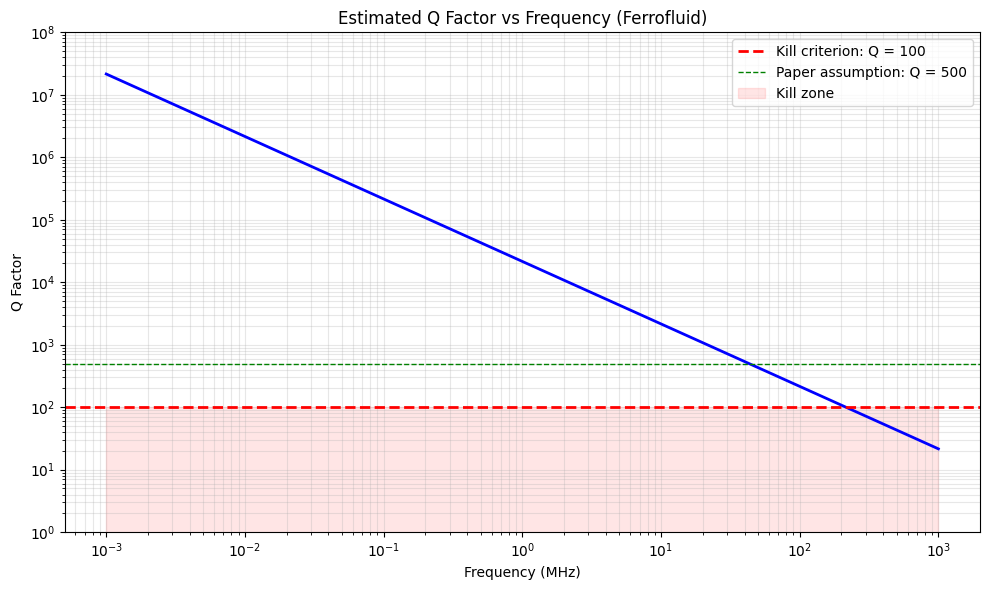

Q drops below 100 above ~215.4 MHz
Operating frequency must stay below this for viable resonance.


In [2]:
freqs = np.logspace(3, 9, 100)  # 1 kHz – 1 GHz
Q_vals = np.array([estimate_Q(spec, f) for f in freqs])

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(freqs / 1e6, Q_vals, 'b-', lw=2)
ax.axhline(y=100, color='r', ls='--', lw=2, label='Kill criterion: Q = 100')
ax.axhline(y=500, color='g', ls='--', lw=1, label='Paper assumption: Q = 500')
ax.fill_between(freqs / 1e6, 0, 100, alpha=0.1, color='red', label='Kill zone')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Q Factor')
ax.set_title('Estimated Q Factor vs Frequency (Ferrofluid)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(1, 1e8)
plt.tight_layout()
plt.show()

# Find crossover frequency where Q < 100
kill_idx = np.searchsorted(-Q_vals, -100)
if kill_idx < len(freqs):
    print(f'Q drops below 100 above ~{freqs[kill_idx]/1e6:.1f} MHz')
    print(f'Operating frequency must stay below this for viable resonance.')
else:
    print('Q > 100 across entire frequency range — excellent.')

## Sound Velocity vs Temperature

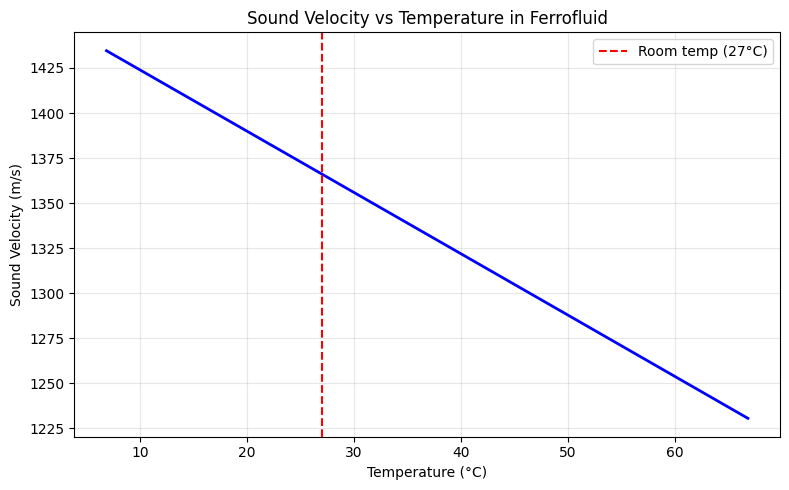

Measured α ≈ 0.0025 /K
Paper assumes α = 0.0022 /K
Model-to-paper ratio: 1.13×


In [3]:
T_range, v_arr = sound_velocity_sweep(spec)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_range - 273.15, v_arr, 'b-', lw=2)
ax.axvline(x=27, color='r', ls='--', label='Room temp (27°C)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Sound Velocity (m/s)')
ax.set_title('Sound Velocity vs Temperature in Ferrofluid')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

v_300 = sound_velocity(spec, 300)
v_305 = sound_velocity(spec, 305)
alpha_meas = abs(v_305 - v_300) / v_300 / 5.0
print(f'Measured α ≈ {alpha_meas:.4f} /K')
print(f'Paper assumes α = 0.0022 /K')
print(f'Model-to-paper ratio: {alpha_meas / 0.0022:.2f}×')

## Magneto-Viscous Effect

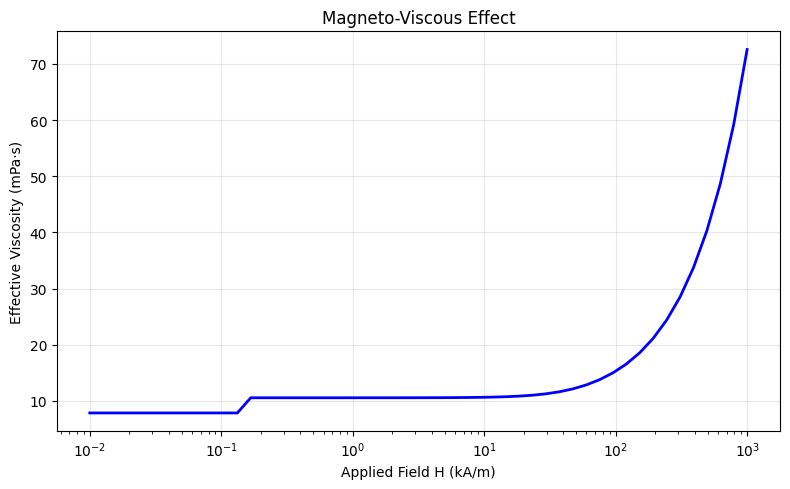

Viscosity at H=0: 7.87 mPa·s
Viscosity at H=10 kA/m: 10.66 mPa·s
Viscosity at H=100 kA/m: 15.30 mPa·s

The applied field can tune damping — this is the mechanism behind ZIM-like control.


In [4]:
H_range = np.logspace(1, 6, 50)  # 10 – 1M A/m
eta_vals = np.array([effective_viscosity(spec, H=H) for H in H_range])

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(H_range / 1000, eta_vals * 1000, 'b-', lw=2)
ax.set_xlabel('Applied Field H (kA/m)')
ax.set_ylabel('Effective Viscosity (mPa·s)')
ax.set_title('Magneto-Viscous Effect')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Viscosity at H=0: {effective_viscosity(spec, H=0)*1000:.2f} mPa·s')
print(f'Viscosity at H=10 kA/m: {effective_viscosity(spec, H=1e4)*1000:.2f} mPa·s')
print(f'Viscosity at H=100 kA/m: {effective_viscosity(spec, H=1e5)*1000:.2f} mPa·s')
print(f'\nThe applied field can tune damping — this is the mechanism behind ZIM-like control.')

## Kill Criteria Assessment

In [5]:
criteria = check_kill_criteria(char)

print('=' * 70)
print('PHASE 1 KILL CRITERIA — FERROFLUID MATERIAL MODEL')
print('=' * 70)
print(f'{"Criterion":<25} {"Value":>15} {"Threshold":>15} {"Status":>10}')
print('-' * 70)
for name, (value, threshold, status) in criteria.items():
    icon = '✅' if status == 'PASS' else ('⚠️' if status == 'WARN' else '❌')
    print(f'{icon} {name:<23} {value:>15.2f} {threshold:>15} {status:>10}')

print()
print('⚠️  These are MODEL estimates based on classical absorption theory.')
print('   Real ferrofluid Q factors need experimental measurement.')
print('   The model suggests Q >> 100 at MHz frequencies — encouraging.')
print('   Key uncertainty: nonlinear losses, particle clustering, and')
print('   scattering effects not captured by this model.')

PHASE 1 KILL CRITERIA — FERROFLUID MATERIAL MODEL
Criterion                           Value       Threshold     Status
----------------------------------------------------------------------
✅ Q at 1 MHz                     21523.74           > 100       PASS
✅ Q at 10 MHz                     2152.37           > 100       PASS
✅ Sound velocity                  1366.64    800–2000 m/s       PASS
✅ Viscosity (no field)               0.01      < 0.1 Pa·s       PASS

⚠️  These are MODEL estimates based on classical absorption theory.
   Real ferrofluid Q factors need experimental measurement.
   The model suggests Q >> 100 at MHz frequencies — encouraging.
   Key uncertainty: nonlinear losses, particle clustering, and
   scattering effects not captured by this model.
